# Blog Writer Agent with LangGraph improved


In [1]:
%pip install -q langchain langgraph langchain-ollama pydantic

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [2]:
from __future__ import annotations

import json
import operator
from typing import TypedDict, List, Annotated
from pathlib import Path

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_ollama import ChatOllama  # Modern Ollama integration
from langchain_core.messages import HumanMessage

c:\Users\Eshan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## LLM Setup

Using `ChatOllama` with `qwen2.5`. Change the model name here if you want to use a different one (e.g. `llama3.2`, `mistral`).

In [3]:
llm = ChatOllama(
    model="qwen2.5",   # change to any model you have pulled in ollama
    temperature=0.3
)

# Quick sanity check
print(llm.invoke("Say hello in one sentence.").content)

Hello there! How can I assist you today?


## Data Models

In [4]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="What the reader should understand after this section."
    )

    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="Concrete subpoints the section must cover."
    )

    target_words: int = Field(
        ...,
        description="Approximate length of the section."
    )


class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description="Who the blog is for")
    tone: str = Field(..., description="Writing tone")
    tasks: List[Task]

## LangGraph State

In [5]:
class State(TypedDict):
    topic: str
    plan: Plan
    # operator.add is the reducer — sections from all workers are auto-concatenated
    sections: Annotated[List[str], operator.add]
    final: str  # final stitched blog

## Agent Nodes

### 1. Orchestrator — creates the blog plan

In [6]:
def orchestrator(state: State) -> dict:

    prompt = f"""
You are a senior technical writer.

Create a detailed blog plan for the topic: {state['topic']}

Requirements:
- 5–7 sections
- Each section must include:
  1. title
  2. goal (what reader learns)
  3. 3–5 bullet points
  4. target word count (120–450)

Return ONLY valid JSON with this format:

{{
  "blog_title": "...",
  "audience": "...",
  "tone": "...",
  "tasks": [
    {{
      "id": 1,
      "title": "...",
      "goal": "...",
      "bullets": ["...", "..."],
      "target_words": 200
    }}
  ]
}}
"""

    response = llm.invoke(prompt).content.strip()

    plan_dict = json.loads(response)
    plan = Plan(**plan_dict)
    print(f"[Orchestrator] Plan created: '{plan.blog_title}' with {len(plan.tasks)} sections")
    return {"plan": plan}


### 2. Fan-out — sends each task to a worker in parallel

In [7]:
def fanout(state: State):
    """Distributes tasks across parallel worker nodes."""
    return [
        Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
        for task in state["plan"].tasks
    ]

### 3. Worker — writes one blog section

In [8]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    prompt = f"""
You are writing ONE section of a technical blog.

Blog title: {plan.blog_title}
Audience: {plan.audience}
Tone: {plan.tone}

Section title: {task.title}

Goal:
{task.goal}

Cover ALL these bullets in order:
{bullets_text}

Target length: {task.target_words} words

Write clean markdown starting with:

## {task.title}
"""

    section_md = llm.invoke(prompt).content.strip()

    print(f"[Worker] Done: {task.title}")

    return {"sections": [section_md]}

### 4. Reducer — stitches everything into the final blog

In [9]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body  = "\n\n".join(state["sections"]).strip()
    final_md = f"# {title}\n\n{body}\n"

    # Save to a markdown file
    filename = "".join(c for c in title if c.isalnum() or c in (" ", "_", "-"))
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    print(f"[Reducer] Blog saved to: {output_path.resolve()}")

    return {"final": final_md}

## Build & Compile the Graph

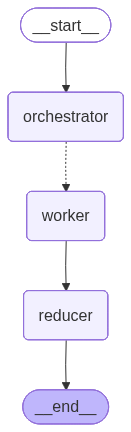

In [10]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

## Run the Agent

In [11]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

[Orchestrator] Plan created: 'Understanding Self-Attention: A Key Component in Modern NLP Models' with 5 sections
[Worker] Done: Self-Attention in Transformer Models
[Worker] Done: How Self-Attention Works
[Worker] Done: Applications of Self-Attention
[Worker] Done: Introduction to Self-Attention
[Worker] Done: Challenges and Future Directions
[Reducer] Blog saved to: C:\Users\Eshan\OneDrive\Desktop\ML_LAB_PROJECTS\blog_writing_agent\understanding_self-attention_a_key_component_in_modern_nlp_models.md


## Display the Final Blog

In [12]:
from IPython.display import Markdown
Markdown(out["final"])

# Understanding Self-Attention: A Key Component in Modern NLP Models

## Introduction to Self-Attention

Self-attention, a key component in modern NLP models, has revolutionized the way we process and understand text data. At its core, self-attention allows a model to weigh the importance of different words in a sentence relative to each other, enabling it to capture complex relationships and context more effectively. This mechanism is particularly crucial for tasks such as translation, text summarization, and sentiment analysis, where understanding the nuances of language is essential.

### Define self-attention and explain its role in NLP

Self-attention, also known as multi-head self-attention, is a mechanism that allows the model to focus on different parts of the input sequence when generating each element of the output sequence. It was introduced in the seminal paper "Attention Is All You Need" by Vaswani et al. (2017) and has since become a cornerstone of transformer-based models. In self-attention, each position in the sequence attends to all other positions, computing a weighted sum of the values associated with those positions. This process is repeated multiple times, allowing the model to capture various levels of context.

### Discuss the limitations of traditional models without self-attention

Traditional NLP models, such as recurrent neural networks (RNNs) and long short-term memory networks (LSTMs), process sequences in a sequential manner. While these models are effective for capturing long-term dependencies, they have limitations when it comes to handling large sequences or parallel processing. RNNs, for instance, suffer from the vanishing gradient problem, making it difficult for them to learn long-term dependencies. Similarly, LSTMs, while addressing some of these issues, still rely on a sequential processing paradigm, which can be computationally expensive and limiting in terms of parallelization.

### Highlight the benefits of self-attention in enhancing model performance

Self-attention addresses these limitations by allowing the model to process the entire sequence in parallel, significantly reducing computational complexity. Moreover, by enabling the model to weigh the importance of different words relative to each other, self-attention can capture more nuanced and context-rich representations. This is particularly beneficial for tasks that require a deep understanding of the context, such as machine translation, where the meaning of a word can change based on its surrounding context.

In summary, self-attention is a powerful mechanism that enhances the ability of NLP models to understand and process text data. By allowing the model to focus on relevant parts of the input sequence, self-attention has led to significant improvements in model performance across a wide range of NLP tasks.

## How Self-Attention Works

Self-attention, a key component in modern NLP models, allows the model to weigh the importance of different words in a sentence relative to each other. This mechanism is particularly powerful because it enables the model to capture long-range dependencies and context, which are crucial for tasks like translation, text summarization, and sentiment analysis.

### Calculating Attention Scores

The process of calculating attention scores begins with the model receiving a sequence of vectors, each representing a word in the sentence. For a sentence with \( n \) words, the model generates \( n \) vectors, each of dimension \( d \). The attention mechanism then computes a score for each pair of words, indicating how much one word should attend to the other.

To calculate the attention score between two words, the model first computes the dot product of their respective query vector \( Q \) and key vector \( K \). This dot product is then scaled by the square root of the dimension \( d \) to ensure that the score remains within a reasonable range. The formula for the attention score \( \text{score}(Q, K) \) is:

\[ \text{score}(Q, K) = \frac{Q \cdot K}{\sqrt{d}} \]

After computing the scores for all pairs of words, the model applies a softmax function to these scores to convert them into probabilities. The softmax function ensures that the scores are normalized, making them interpretable as attention weights. The attention weight \( \alpha \) for word \( i \) attending to word \( j \) is:

\[ \alpha_{ij} = \text{softmax}(\text{score}(Q_i, K_j)) \]

### Role of Query, Key, and Value Vectors

In the self-attention mechanism, each word in the sequence is represented by three vectors: a query vector \( Q \), a key vector \( K \), and a value vector \( V \). These vectors are derived from the word's vector representation in the model's embedding layer.

- **Query Vector \( Q \)**: This vector is used to query the information that the word is interested in from the key vectors of other words.
- **Key Vector \( K \)**: This vector is used to find the words that the query vector is interested in.
- **Value Vector \( V \)**: This vector contains the actual information that the query vector will attend to.

The attention mechanism computes the weighted sum of the value vectors, where the weights are the attention scores. This weighted sum is the final representation of the word, capturing the context of the entire sentence.

### Illustrating the Concept of Multi-Head Attention

While a single attention head can capture certain types of relationships, multi-head attention allows the model to learn different types of relationships by using multiple attention mechanisms in parallel. Each attention head uses different query, key, and value vectors, which are derived from the same input vectors but through different linear projections.

The output of each attention head is then concatenated, and a linear projection is applied to the concatenated output to produce the final attention output. This process is repeated for each head, and the results from all heads are combined to form the final attention output.

The formula for the multi-head attention output \( \text{MultiHead}(Q, K, V) \) is:

\[ \text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \text{head}_2, \ldots, \text{head}_h) W^O \]

where \( \text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V) \) and \( W^O \) is the final linear projection matrix.

Multi-head attention significantly enhances the model's ability to capture diverse and complex relationships within the text, making it a powerful tool in modern NLP models.

## Self-Attention in Transformer Models

Self-attention, a key component in the transformer architecture, has revolutionized the field of natural language processing (NLP) by enabling models to weigh the importance of different words in a sentence. This section delves into the application of self-attention in both the encoder and decoder, the positional encoding technique, and the overall impact on the model architecture.

### Importance of Self-Attention in the Encoder and Decoder

Self-attention mechanisms allow each position in a sequence to attend to all positions in the sequence. This is particularly important in the context of the encoder and decoder layers within a transformer model.

#### Encoder
In the encoder, self-attention is used to capture the context of the input sequence. Each token in the input sequence can attend to every other token, allowing the model to understand the relationships between different words. This is crucial for tasks like machine translation, where the context of the entire sentence is essential for accurate translation.

#### Decoder
In the decoder, self-attention is used in a masked manner to ensure that the model only attends to the previously generated tokens. This is essential for tasks like text generation, where the model should not have access to future tokens. Additionally, the decoder also uses cross-attention to attend to the encoder's output, allowing it to understand the context from the input sequence.

### Positional Encoding Technique

Since the transformer model processes sequences in a fixed-size vector space, positional information is not inherently present in the input data. To address this, positional encoding is added to the input embeddings. This encoding provides the model with information about the position of each token in the sequence.

The positional encoding is typically a learned parameter that is added to the input embeddings. It is designed such that the model can learn to use the positional information effectively. The positional encoding is usually a sinusoidal function of the position and the token's dimension, ensuring that the model can capture both the absolute and relative positions of the tokens.

### Impact of Self-Attention on the Overall Model Architecture

The introduction of self-attention in the transformer model has several significant impacts on the overall architecture:

1. **Parallelization**: Self-attention allows for parallel processing of the entire sequence, making the model much faster to train and deploy compared to sequential models like RNNs and LSTMs.

2. **Global Context**: Self-attention enables the model to capture long-range dependencies in the sequence, which is crucial for tasks like language understanding and generation.

3. **Scalability**: The transformer architecture scales well with the length of the input sequence, making it suitable for handling long documents and complex tasks.

4. **Efficiency**: By eliminating the need for recurrent connections, the transformer model reduces the computational complexity, making it more efficient and easier to optimize.

In summary, self-attention in the transformer model plays a crucial role in enabling the model to understand and generate text by capturing the context and relationships between words. The positional encoding technique ensures that the model can handle the positional information, while the overall architecture benefits from parallelization, scalability, and efficiency. These features make the transformer model a powerful tool in the field of NLP.

## Applications of Self-Attention

Self-attention, a key component in modern NLP models, has revolutionized the way machines process and understand human language. Its ability to weigh the importance of different words in a sentence or document makes it particularly effective in various NLP tasks. Let's explore some of the applications where self-attention shines.

### Language Translation Models

One of the most prominent applications of self-attention is in language translation models. Models like Google's Transformer and OpenAI's MUSE leverage self-attention mechanisms to understand the context and meaning of sentences in the source language before generating an accurate translation. Self-attention allows these models to capture long-range dependencies and context, which is crucial for translating idiomatic expressions, technical terms, and cultural nuances. For instance, when translating a sentence like "I saw the man with a telescope," self-attention helps the model understand that "telescope" is a tool used by the subject, not a description of the man.

### Sentiment Analysis

Self-attention also plays a crucial role in sentiment analysis, where the goal is to determine the emotional tone behind a piece of text. By focusing on different words and their relationships within a sentence, self-attention can better capture the subtle nuances that contribute to the overall sentiment. For example, in the sentence "The movie was good, but the acting was terrible," self-attention can help the model weigh the positive and negative sentiments more accurately, leading to a more precise sentiment score. This improved accuracy is particularly valuable in applications like customer feedback analysis, where nuanced understanding is critical.

### Question-Answering Systems

In question-answering (QA) systems, self-attention is used to identify the most relevant parts of a document or passage to answer a given question. These systems often employ a combination of self-attention and other techniques like bidirectional encoders (BERT) to understand the context and generate accurate answers. For instance, when asked "What is the capital of France?" a QA system with self-attention can focus on the relevant parts of the passage, such as "France" and "capital," to provide the correct answer. This capability is essential for applications like virtual assistants, where quick and accurate responses are required.

Self-attention's ability to focus on relevant information and capture context makes it a powerful tool in NLP, enhancing the performance of language translation, sentiment analysis, and question-answering systems. As research continues to advance, we can expect even more sophisticated applications of self-attention in the future.

## Challenges and Future Directions

Self-attention mechanisms have revolutionized the field of natural language processing (NLP) by enabling models to weigh the importance of different words in a sentence. However, as these models have grown more complex, they have also introduced several challenges, particularly in terms of computational and memory requirements. Additionally, ongoing research is focused on improving these mechanisms to make them more efficient and effective. Furthermore, the potential of self-attention in multimodal learning is a promising direction for future exploration.

### Computational and Memory Challenges

One of the primary challenges with self-attention is the computational complexity. The standard self-attention mechanism involves calculating the attention scores for every pair of tokens in the input sequence, which results in a time complexity of \(O(n^2)\), where \(n\) is the length of the sequence. This complexity can be prohibitive for long sequences, making real-time processing and large-scale applications difficult. Moreover, the memory requirements for storing the attention scores and intermediate results can be substantial, especially when dealing with large datasets.

To address these challenges, researchers are exploring various optimization techniques. For instance, techniques such as sparse attention, where only a subset of tokens are considered for attention, can significantly reduce the computational load. Additionally, methods like linear attention, which avoid the quadratic complexity by using linear operations, are being investigated. These approaches aim to strike a balance between performance and efficiency, making self-attention more viable for practical applications.

### Ongoing Research in Improving Self-Attention Mechanisms

Improving self-attention mechanisms is an active area of research. One direction is to enhance the efficiency of the attention mechanism itself. This includes developing more sophisticated algorithms that can handle large sequences more effectively. Another approach is to integrate self-attention with other techniques, such as transformers, to create hybrid models that leverage the strengths of both methods.

Moreover, there is a focus on making self-attention more interpretable and controllable. This involves developing methods to better understand how the attention mechanism works and to control its behavior, which can be crucial for applications where interpretability is important, such as in legal or medical text analysis.

### Potential of Self-Attention in Multimodal Learning

The future of self-attention extends beyond NLP into the realm of multimodal learning, where it can be used to process and analyze data from multiple modalities, such as text, images, and audio. Self-attention can help in aligning and integrating information from different modalities, enabling more comprehensive and context-aware models. For example, in a scenario where text and images are both available, self-attention can help in understanding the relationship between the text and the visual content, enhancing the model's ability to generate more accurate and contextually rich outputs.

In conclusion, while self-attention has already made significant strides in NLP, ongoing research is crucial to address the computational and memory challenges and to explore its potential in multimodal learning. These advancements will pave the way for more powerful and versatile models that can handle complex and diverse data.
